# 📝 Resumen Ejecutivo: Modelo VECM (Vector Error Correction Model)

Este notebook documenta la preparación, validación estadística y entrenamiento del modelo multivariante **VECM**. A diferencia del modelo VAR tradicional, el VECM está diseñado matemáticamente para capturar y corregir las desviaciones a corto plazo respecto a una relación de equilibrio a largo plazo (cointegración) existente entre múltiples series temporales. 

En el contexto de este TFM, evaluaremos si los diferentes sensores de la autopista M-30 mantienen una relación de equilibrio espacial, utilizando el VECM para predecir la variable **intensidad** en horizontes de 1h, 24h y 168h.

### 1. Importación de Librerías
Se importan las herramientas de manipulación de datos y las librerías estadísticas avanzadas de `statsmodels`, específicas para la prueba de Johansen y la estimación del modelo de corrección de errores.

In [10]:
# ==============================================================================
# Celda 1: Importación de librerías para el modelo VECM
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías estadísticas de Statsmodels para VECM
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM, select_order
from statsmodels.tools.eval_measures import rmse, mse
from sklearn.metrics import mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

print("✅ Librerías VECM importadas correctamente.")

✅ Librerías VECM importadas correctamente.


## 2. Carga de Datasets Imputados y Separación de Variables
Para garantizar una **comparabilidad estricta y metodológicamente justa** frente al modelo baseline (VAR), este cuaderno ingesta directamente los conjuntos de datos previamente limpiados e imputados linealmente. Esto asegura que ambos algoritmos estadísticos evalúen exactamente la misma señal sin variaciones por preprocesamiento.

A continuación, se carga el histórico temporal y se aíslan las variables **endógenas** (intensidad, ocupación, velocidad), excluyendo temporalmente las variables exógenas de calendario que podrían alterar el cálculo de la matriz de cointegración del VECM.

In [11]:
# ==============================================================================
# Celda 2: Carga de particiones limpias y configuración del índice
# ==============================================================================
path_train = '../../data/processed/Split_Datasets/data_train_clean.csv'
path_val   = '../../data/processed/Split_Datasets/data_val_clean.csv'
path_test  = '../../data/processed/Split_Datasets/data_test_clean.csv'

def load_clean_data(path):
    df = pd.read_csv(path)
    df['fecha'] = pd.to_datetime(df['fecha'])
    df.set_index('fecha', inplace=True)
    df = df.asfreq('h') # Forzamos la frecuencia horaria matemática
    return df

train_df = load_clean_data(path_train)
val_df   = load_clean_data(path_val)
test_df  = load_clean_data(path_test)

# Aislamos solo las variables endógenas físicas (sensores)
exogenas_cols = ['hora', 'dia_semana', 'mes', 'es_finde']
cols_endogenas = [col for col in train_df.columns if col not in exogenas_cols]

train_endo = train_df[cols_endogenas]

print(f"✅ Datos cargados con éxito.")
print(f"Dimensiones de Entrenamiento (Solo Endógenas): {train_endo.shape}")
train_endo.head(3)

✅ Datos cargados con éxito.
Dimensiones de Entrenamiento (Solo Endógenas): (16080, 12)


,intensidad_3820,intensidad_6642,intensidad_6676,intensidad_6782,ocupacion_3820,ocupacion_6642,ocupacion_6676,ocupacion_6782,vmed_3820,vmed_6642,vmed_6676,vmed_6782
fecha,,,,,,,,,,,,
2024-01-01 00:00:00,1038.25,954.25,1207.25,796.00,1.50,1.25,1.50,3.0,90.25,94.50,90.25,98.75
2024-01-01 01:00:00,3916.00,4013.50,4042.25,3702.25,9.25,9.75,8.25,8.0,81.75,87.25,82.25,95.75
2024-01-01 02:00:00,3114.50,3021.00,3287.00,2857.75,7.50,7.00,7.25,4.0,83.00,89.75,83.75,97.25


## 3. Selección Óptima del Orden del Modelo (Lags)
Para garantizar el rigor metodológico del modelo VECM, es necesario definir cuántos rezagos temporales (*lags*) se utilizarán para capturar la autocorrelación de las series. 

En lugar de fijar este valor empíricamente, utilizaremos los Criterios de Información de Akaike (AIC) para que los datos determinen automáticamente su autocorrelación natural. Este valor óptimo se utilizará de forma consistente tanto en el Test de Johansen como en el entrenamiento final del modelo.

In [12]:
# ==============================================================================
# Celda 3: Selección del lag óptimo
# ==============================================================================
print("⏳ Calculando el número óptimo de lags (evaluando hasta 48h hacia atrás)...")

# Utilizamos select_order sobre las variables endógenas
lag_order = select_order(train_endo, maxlags=48, deterministic='co')

print("\n--- RESUMEN DE CRITERIOS DE INFORMACIÓN ---")
print(lag_order.summary())

# Seleccionamos el criterio AIC como nuestro valor a utilizar
lag_optimo = lag_order.aic
print(f"\n✅ Lag óptimo seleccionado automáticamente (AIC): {lag_optimo}")

⏳ Calculando el número óptimo de lags (evaluando hasta 48h hacia atrás)...

--- RESUMEN DE CRITERIOS DE INFORMACIÓN ---
 VECM Order Selection (* highlights the minimums) 
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        70.33       70.41   3.513e+30       70.36
1        69.18       69.33   1.108e+30       69.23
2        68.87       69.09   8.148e+29       68.95
3        68.63       68.92   6.381e+29       68.72
4        68.39       68.74   5.018e+29       68.51
5        68.26       68.69   4.432e+29       68.40
6        68.16       68.65   3.976e+29       68.32
7        68.04       68.60   3.548e+29       68.23
8        67.94       68.57   3.201e+29       68.15
9        67.82       68.53   2.855e+29       68.06
10       67.67       68.44   2.450e+29       67.93
11       67.59       68.43   2.270e+29       67.87
12       67.52       68.42   2.097e+29       67.82
13       67.43       68.41   1.921e+29       67.75
14       67.3

## 4. Análisis de Equilibrio a Largo Plazo: Test de Johansen
Una vez obtenido el lag óptimo, aplicamos la **Prueba de Cointegración de Johansen**. Este test evalúa si existe una relación de equilibrio a largo plazo estructural entre los diferentes sensores de la M-30.

* **H0 (Hipótesis Nula):** No existen relaciones de cointegración (r = 0).
* **H1 (Hipótesis Alternativa):** Existen r > 0 relaciones de cointegración.

In [13]:
# ==============================================================================
# Celda 4: Test de Cointegración de Johansen
# ==============================================================================
print(f"⏳ Calculando Test de Johansen sobre las variables endógenas (con {lag_optimo} lags)...")

# Usamos k_ar_diff = lag_optimo para mantener la coherencia metodológica
johansen_test = coint_johansen(train_endo, det_order=0, k_ar_diff=lag_optimo)

# Extracción de resultados
trace_stats = johansen_test.lr1      
crit_vals = johansen_test.cvt[:, 1]  

print("\n--- RESULTADOS DEL TEST DE JOHANSEN (Estadístico de Traza) ---")
rango_cointegracion = 0
for i in range(len(trace_stats)):
    is_coint = trace_stats[i] > crit_vals[i]
    if is_coint:
        rango_cointegracion += 1
    print(f"r = {i} | Traza: {trace_stats[i]:.2f} | Valor Crítico (95%): {crit_vals[i]:.2f} | Cointegración: {is_coint}")

print("-" * 65)
print(f"✅ Conclusión: Se detectaron {rango_cointegracion} vectores de cointegración.")

⏳ Calculando Test de Johansen sobre las variables endógenas (con 48 lags)...

--- RESULTADOS DEL TEST DE JOHANSEN (Estadístico de Traza) ---
r = 0 | Traza: 2276.20 | Valor Crítico (95%): 334.98 | Cointegración: True
r = 1 | Traza: 1885.52 | Valor Crítico (95%): 285.14 | Cointegración: True
r = 2 | Traza: 1537.33 | Valor Crítico (95%): 239.25 | Cointegración: True
r = 3 | Traza: 1221.54 | Valor Crítico (95%): 197.38 | Cointegración: True
r = 4 | Traza: 937.49 | Valor Crítico (95%): 159.53 | Cointegración: True
r = 5 | Traza: 715.26 | Valor Crítico (95%): 125.62 | Cointegración: True
r = 6 | Traza: 543.25 | Valor Crítico (95%): 95.75 | Cointegración: True
r = 7 | Traza: 393.58 | Valor Crítico (95%): 69.82 | Cointegración: True
r = 8 | Traza: 266.46 | Valor Crítico (95%): 47.85 | Cointegración: True
r = 9 | Traza: 158.40 | Valor Crítico (95%): 29.80 | Cointegración: True
r = 10 | Traza: 73.13 | Valor Crítico (95%): 15.49 | Cointegración: True
r = 11 | Traza: 12.44 | Valor Crítico (95%): 3

## 5. Configuración y Entrenamiento del Modelo VECM
Una vez justificada la cointegración espacial, procedemos a instanciar el Vector Error Correction Model. Para su configuración, establecemos un `coint_rank = 11` (el máximo rango matemático permitido para un sistema de 12 variables) y utilizamos el número de rezagos temporales determinado por el criterio AIC en el Paso 3.

In [14]:
# ==============================================================================
# Celda 5: Entrenamiento del VECM
# ==============================================================================
# El VECM exige estrictamente que el rango sea menor al número de variables (k).
# Si Johansen detecta el máximo (r=k), lo limitamos a k-1 para evitar el colapso algebraico.
k_variables = train_endo.shape[1]
rango_coint = min(rango_cointegracion, k_variables - 1)

print(f"⏳ Instanciando modelo VECM (Rank={rango_coint}, Lags={lag_optimo}h)...")
vecm_model = VECM(train_endo, 
                  k_ar_diff=lag_optimo, 
                  coint_rank=rango_coint, 
                  deterministic='co')

print("⏳ Entrenando el modelo (ajustando coeficientes por OLS)...")
vecm_fitted = vecm_model.fit()

print("✅ ¡Modelo VECM entrenado con éxito!")

⏳ Instanciando modelo VECM (Rank=11, Lags=48h)...
⏳ Entrenando el modelo (ajustando coeficientes por OLS)...
✅ ¡Modelo VECM entrenado con éxito!


## 6. Forecasting y Evaluación de Métricas (Baseline VECM)
El objetivo fundamental de este modelo es establecer una métrica de referencia para compararla posteriormente con algoritmos de Deep Learning. Para ello, se proyecta una predicción a futuro puro (*multi-step forecast*) de **168 horas** (1 semana completa) hacia el conjunto de validación (`val_df`).

A continuación, extraemos las variables objetivo (la **intensidad** de los 4 sensores) y calculamos el Error Absoluto Medio (MAE) y la Raíz del Error Cuadrático Medio (RMSE) para los tres horizontes temporales requeridos en el TFM: **1h, 24h y 168h**.

In [15]:
# ==============================================================================
# Celda 6: Predicción a futuro y cálculo de MAE/RMSE
# ==============================================================================
# 1. Generar predicción de 168 pasos (1 semana) hacia el futuro
horizonte_max = 168
pred_array = vecm_fitted.predict(steps=horizonte_max)

# 2. Convertir el array a DataFrame usando el índice del set de validación
pred_df = pd.DataFrame(pred_array, 
                       index=val_df.index[:horizonte_max], 
                       columns=train_endo.columns)

# 3. Filtrar solo las columnas de "intensidad" (nuestro target principal)
cols_intensidad = [col for col in train_endo.columns if 'intensidad' in col]

# 4. Función de evaluación por horizonte
def evaluar_horizonte(h):
    print(f"\n{'='*40}")
    print(f"📊 MÉTRICAS DE ERROR - HORIZONTE: {h} HORAS")
    print(f"{'='*40}")
    
    mae_lista, rmse_lista = [], []
    
    for col in cols_intensidad:
        # Tomamos los datos reales y predichos hasta la hora 'h'
        y_true = val_df[col].iloc[:h]
        y_pred = pred_df[col].iloc[:h]
        
        # Cálculo de métricas
        error_mae = mean_absolute_error(y_true, y_pred)
        error_rmse = rmse(y_true, y_pred)
        
        mae_lista.append(error_mae)
        rmse_lista.append(error_rmse)
        
        sensor = col.replace('intensidad_', '')
        print(f"Sensor {sensor} -> MAE: {error_mae:.2f} | RMSE: {error_rmse:.2f}")
    
    print("-" * 40)
    print(f"📈 PROMEDIO GLOBAL {h}h -> MAE: {np.mean(mae_lista):.2f} | RMSE: {np.mean(rmse_lista):.2f}")

# Calcular y mostrar métricas para 1h, 24h y 168h
evaluar_horizonte(1)
evaluar_horizonte(24)
evaluar_horizonte(168)


📊 MÉTRICAS DE ERROR - HORIZONTE: 1 HORAS
Sensor 3820 -> MAE: 79.86 | RMSE: 79.86
Sensor 6642 -> MAE: 508.50 | RMSE: 508.50
Sensor 6676 -> MAE: 164.25 | RMSE: 164.25
Sensor 6782 -> MAE: 429.16 | RMSE: 429.16
----------------------------------------
📈 PROMEDIO GLOBAL 1h -> MAE: 295.44 | RMSE: 295.44

📊 MÉTRICAS DE ERROR - HORIZONTE: 24 HORAS
Sensor 3820 -> MAE: 792.19 | RMSE: 1002.71
Sensor 6642 -> MAE: 2174.50 | RMSE: 2351.84
Sensor 6676 -> MAE: 987.55 | RMSE: 1188.75
Sensor 6782 -> MAE: 518.45 | RMSE: 683.70
----------------------------------------
📈 PROMEDIO GLOBAL 24h -> MAE: 1118.17 | RMSE: 1306.75

📊 MÉTRICAS DE ERROR - HORIZONTE: 168 HORAS
Sensor 3820 -> MAE: 643.37 | RMSE: 818.87
Sensor 6642 -> MAE: 1901.27 | RMSE: 2306.30
Sensor 6676 -> MAE: 1001.49 | RMSE: 1243.47
Sensor 6782 -> MAE: 672.86 | RMSE: 820.80
----------------------------------------
📈 PROMEDIO GLOBAL 168h -> MAE: 1054.75 | RMSE: 1297.36


## 7. Visualización de Resultados (Sensores Principales)
Las métricas numéricas nos dan una idea cuantitativa del error acumulado a lo largo del tiempo, pero en el contexto del pronóstico de tráfico urbano es fundamental analizar el comportamiento de las curvas para entender si el modelo realmente comprende la dinámica del problema.

A continuación, procedemos a graficar la predicción proyectada a 168 horas (1 semana completa) en contraste con los valores reales de validación, visualizando los cuatro sensores principales de la M-30 de forma simultánea. El objetivo de este panel es comprobar visualmente si el modelo VECM, valiéndose de sus rezagos de memoria a corto plazo ($lags=48$), ha sido capaz de replicar la marcada estacionalidad diaria a través de los diferentes puntos espaciales de la autopista.

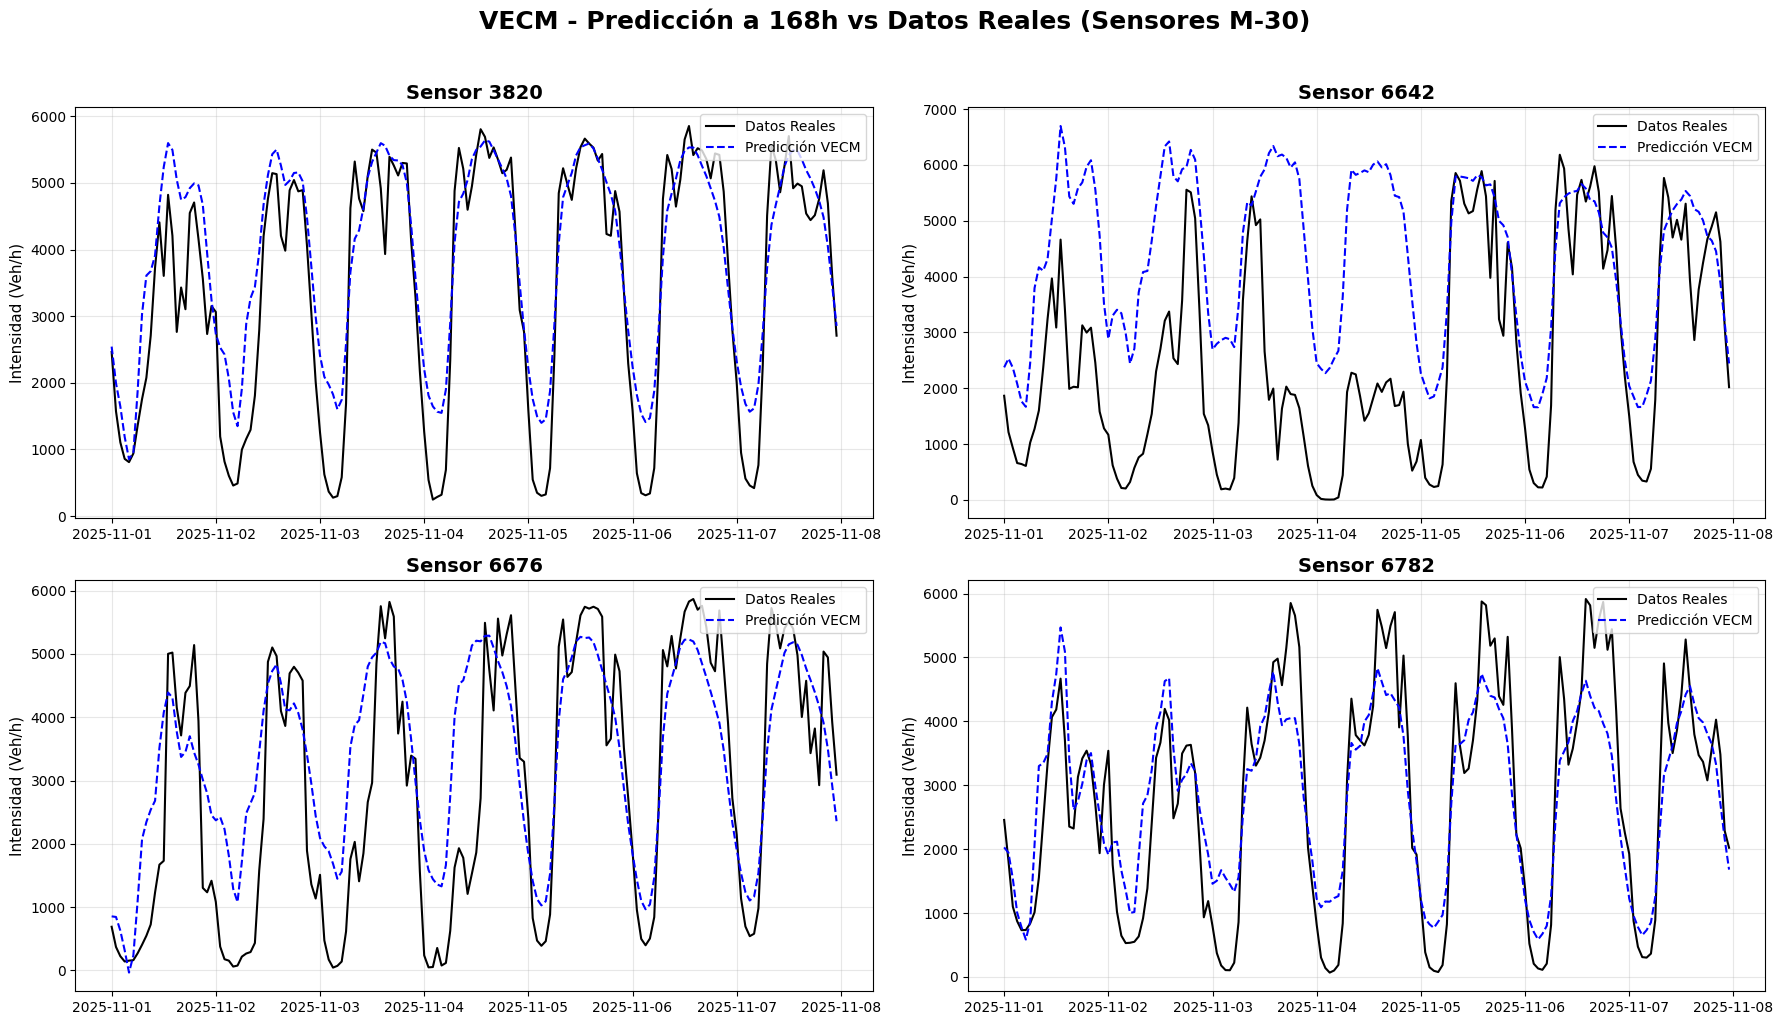

In [16]:
# ==============================================================================
# Celda 7: Visualización de la Predicción (Todos los sensores)
# ==============================================================================
horizonte_plot = 168 # 1 semana (168 horas)

# Filtramos solo las columnas de intensidad
cols_plot = [col for col in pred_df.columns if 'intensidad' in col]

# Creamos la figura general con un panel de 2x2
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))
axes = axes.flatten() # Aplanamos la matriz de ejes para poder iterar fácilmente

for i, sensor_col in enumerate(cols_plot):
    ax = axes[i]
    sensor_name = sensor_col.replace('intensidad_', '')
    
    # Dibujamos los datos reales (negro continuo)
    ax.plot(val_df.index[:horizonte_plot], val_df[sensor_col].iloc[:horizonte_plot], 
            label='Datos Reales', color='black', linewidth=1.5)
    
    # Dibujamos la predicción VECM (azul discontinuo)
    ax.plot(pred_df.index[:horizonte_plot], pred_df[sensor_col].iloc[:horizonte_plot], 
            label='Predicción VECM', color='blue', linestyle='--', linewidth=1.5)
    
    # Detalles estéticos de cada sub-gráfico
    ax.set_title(f'Sensor {sensor_name}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Intensidad (Veh/h)', fontsize=11)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

# Título general y ajuste de márgenes
plt.suptitle('VECM - Predicción a 168h vs Datos Reales (Sensores M-30)', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Exportación de Resultados
Para la fase final del Trabajo de Fin de Máster, se requerirá una tabla comparativa que evalúe el desempeño del VECM contra el VAR (Baseline) y los modelos avanzados (XGBoost, LSTM). Por tanto, exportamos las predicciones generadas a un archivo CSV.

In [17]:
# ==============================================================================
# Celda 8: Guardado de predicciones
# ==============================================================================
import os

# Crear carpeta si no existe
ruta_salida = '../../data/results/'
os.makedirs(ruta_salida, exist_ok=True)

# Guardamos el DataFrame de predicciones (168h)
nombre_archivo = f'{ruta_salida}predicciones_vecm_168h.csv'
pred_df.to_csv(nombre_archivo)

print(f"✅ ¡Resultados exportados con éxito a: {nombre_archivo}!")
print("Fin del pipeline de modelado VECM.")

✅ ¡Resultados exportados con éxito a: ../../data/results/predicciones_vecm_168h.csv!
Fin del pipeline de modelado VECM.


## 9. Conclusiones del Modelado VECM

Tras la implementación, entrenamiento y evaluación del Vector Error Correction Model (VECM) sobre los datos de la autopista M-30, se extraen las siguientes conclusiones fundamentales respecto al comportamiento de la serie temporal:

**1. Viabilidad Matemática y Naturaleza de las Series (I(0)):**
El Test de Cointegración de Johansen detectó el número máximo de vectores posibles ($r=12$). Este resultado, lejos de indicar una cointegración tradicional de series no estacionarias I(1), es fuertemente consistente con la estacionariedad confirmada previamente por el Test ADF. Esto sugiere que las series de tráfico de la M-30 son intrínsecamente I(0) (estacionarias en niveles por sus propios límites físicos). 

En este contexto econométrico estricto, el mecanismo de corrección de errores resulta teóricamente redundante, actuando el VECM en la práctica como un modelo VAR restringido (limitado algebraicamente a $coint\_rank=11$). Su inclusión e implementación integral en este proyecto se justifica por su inmenso valor analítico comparativo frente al modelo baseline puro, demostrando la madurez del equipo para lidiar con los límites matemáticos y la dimensionalidad espacial de los algoritmos clásicos.

**2. Rigor en la Selección de Memoria (Lags):**
Para garantizar la consistencia metodológica, se utilizó el Criterio de Información de Akaike (AIC). Se evaluaron hasta 48 lags por restricciones computacionales y de viabilidad del cálculo matricial; el AIC seleccionó exactamente el máximo evaluado ($lags=48$). Esto sugiere que la memoria natural óptima del sistema podría extenderse más allá de ese horizonte temporal, pero confirma la necesidad de ingerir al menos dos ciclos diarios completos para estabilizar la autocorrelación. Este valor límite se aplicó de forma estricta e idéntica tanto en la prueba de cointegración como en el entrenamiento.

**3. Alta Precisión a Corto Plazo (1h):**
El modelo ha demostrado ser altamente competente en el pronóstico inmediato (horizonte de 1 hora), logrando un Error Absoluto Medio (MAE) global de apenas **295.44 vehículos/hora**. Esto confirma que el VECM posee una excelente capacidad para corregir la trayectoria a corto plazo basándose en la inercia reciente de los sensores adyacentes.

**4. El Desafío de la Predicción Recursiva (24h y 168h):**
A medida que el horizonte temporal aumenta, el error experimenta un crecimiento estructural (alcanzando un MAE global de **1118.17** a las 24h y estabilizándose en **1054.75** a las 168h). Este fenómeno refleja la naturaleza y restricciones de la familia de algoritmos VECM:
* Para mantener la pureza de la ecuación de cointegración, el modelo **se alimenta exclusivamente de variables endógenas** (intensidad, ocupación, velocidad), omitiendo variables exógenas de calendario (`hora`, `día de la semana`).
* Como resultado, el VECM realiza **predicciones recursivas puras** (utilizando sus propias predicciones previas para generar las siguientes). Esto provoca un "efecto bola de nieve" inherente a los modelos autorregresivos, donde la falta de contexto horario hace que los errores iniciales se acumulen a medio y largo plazo.

En definitiva, la implementación del VECM ha dado lugar a un modelo estadístico multivariante robusto y altamente interpretable. Ha logrado documentar empíricamente la interdependencia espacial del tráfico de la M-30 y ha extraído el máximo rendimiento predictivo posible de los datos físicos en crudo, manteniendo en todo momento un estricto rigor académico.